In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import tensorflow.keras as tk

In [2]:
mnist = tk.datasets.mnist

In [3]:
(train_img, train_labels), (test_img, test_labels) = mnist.load_data()

In [4]:
print(train_img.shape)

(60000, 28, 28)


In [19]:
class MyNetwork(tk.Model):
    def __init__(self):
        super(MyNetwork, self).__init__()
        self.flatten = tk.layers.Flatten(input_shape=(28, 28))
        self.layer1 = tk.layers.Dense(64, activation=None, use_bias=False)
        self.layer2 = tk.layers.Dense(32, activation=None, use_bias=False)
        self.layer3 = tk.layers.Dense(16, activation=None, use_bias=False)
        self.out = tk.layers.Dense(10, activation=None, use_bias=False)
    
    def call(self, inp):
        a0 = self.flatten(inp)
        s1 = self.layer1(a0)
        a1 = tf.math.sigmoid(s1)
        s2 = self.layer2(a1)
        a2 = tf.math.sigmoid(s2)
        s3 = self.layer3(a2)
        a3 = tf.math.sigmoid(s3)
        s4 = self.out(a3)
        a4 = tf.nn.softmax(s4)
        return a4, [a0, a1, a2, a3, a4], [s1, s2, s3, s4]

In [43]:
model = MyNetwork()
optimizer = tf.keras.optimizers.Adam()
cce = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
m = tf.keras.metrics.Accuracy()
adam_losses = []
for i in range(1000):
    inds = np.random.choice(train_img.shape[0], 128)
    batch_img = tf.convert_to_tensor(train_img[inds], dtype=tf.float32)
    batch_labels = tf.one_hot(train_labels[inds], 10)
    with tf.GradientTape() as tape:
        loss = cce(batch_labels, model(batch_img)[0])
    optimizer.apply_gradients(zip(tape.gradient(loss, model.trainable_weights), model.trainable_weights))
    adam_losses.append(loss)
    if i % 100 == 0:
        print(loss)
        val_inds = np.random.choice(test_img.shape[0], 128)
        val_img = tf.convert_to_tensor(test_img[val_inds], dtype=tf.float32)
        val_labels = tf.convert_to_tensor(test_labels[val_inds])
        pred = tf.math.argmax(model(val_img)[0], axis=-1)
        m.update_state(pred, val_labels)
        print(m.result().numpy())
        m.reset_states()

tf.Tensor(2.4710364, shape=(), dtype=float32)
0.1171875
tf.Tensor(2.078923, shape=(), dtype=float32)
0.5546875
tf.Tensor(1.727633, shape=(), dtype=float32)
0.671875
tf.Tensor(1.4240353, shape=(), dtype=float32)
0.7734375
tf.Tensor(1.0794398, shape=(), dtype=float32)
0.7734375
tf.Tensor(1.0156987, shape=(), dtype=float32)
0.8515625
tf.Tensor(0.80354476, shape=(), dtype=float32)
0.8359375
tf.Tensor(0.7212026, shape=(), dtype=float32)
0.9140625
tf.Tensor(0.5174966, shape=(), dtype=float32)
0.8515625
tf.Tensor(0.7939638, shape=(), dtype=float32)
0.875


In [37]:
@tf.function
def kronecker_product(mat1, mat2):
    """Computes the Kronecker product two matrices."""
    m1, n1 = mat1.get_shape().as_list()
    mat1_rsh = tf.reshape(mat1, [m1, 1, n1, 1])
    m2, n2 = mat2.get_shape().as_list()
    mat2_rsh = tf.reshape(mat2, [1, m2, 1, n2])
    return tf.reshape(mat1_rsh * mat2_rsh, [m1 * m2, n1 * n2])

In [44]:
model = MyNetwork()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
cce = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
m = tf.keras.metrics.Accuracy()
kfac_losses = [] 

@tf.function
def compute_natural_gradient(grads, a, e):
    result = [None]*len(grads)
    for j in range(len(e)):
        eaa = tf.transpose(a[j]) @ (a[j]/a[j].shape[0])
        eee = tf.transpose(e[j]) @ (e[j]/e[j].shape[0])
        l_a, Q_a = tf.linalg.eigh(eaa)
        l_e, Q_e = tf.linalg.eigh(eee)
        damping = 1e-3
        v = grads[j]
        #v = Q_a@v@tf.linalg.matrix_transpose(Q_e)
        v = tf.linalg.matrix_transpose(Q_a)@v@Q_e
        v = v / (l_a[:,None] * l_e[None,:] + damping)
        #v = tf.linalg.matrix_transpose(Q_a)@v@Q_e
        result[j] = Q_a@v@tf.linalg.matrix_transpose(Q_e)
    return result

@tf.function
def get_grads(model, batch, targets):
    with tf.GradientTape(True) as tape:
        logits, a, s = model(batch)
        loss = cce(targets, logits)
    e = tape.gradient(loss, s)
    grads = tape.gradient(loss, model.trainable_weights)
    grads = compute_natural_gradient(grads, a, e)
    return grads, loss

for i in range(1000):
    inds = np.random.choice(train_img.shape[0], 128)
    batch_img = tf.convert_to_tensor(train_img[inds], dtype=tf.float32)
    batch_labels = tf.one_hot(train_labels[inds], 10)
    grads, loss = get_grads(model, batch_img, batch_labels)
    kfac_losses.append(loss)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    if i % 100 == 0:
        print(loss)
        val_inds = np.random.choice(test_img.shape[0], 128)
        val_img = tf.convert_to_tensor(test_img[val_inds], dtype=tf.float32)
        val_labels = tf.convert_to_tensor(test_labels[val_inds])
        pred = tf.math.argmax(model(val_img)[0], axis=-1)
        m.update_state(pred, val_labels)
        print(m.result().numpy())
        m.reset_states()

tf.Tensor(2.4814913, shape=(), dtype=float32)
0.140625
tf.Tensor(1.1165917, shape=(), dtype=float32)
0.671875
tf.Tensor(0.79864824, shape=(), dtype=float32)
0.734375
tf.Tensor(0.6044776, shape=(), dtype=float32)
0.8125
tf.Tensor(0.747363, shape=(), dtype=float32)
0.8125
tf.Tensor(0.5302933, shape=(), dtype=float32)
0.8515625
tf.Tensor(0.6217912, shape=(), dtype=float32)
0.8671875
tf.Tensor(0.5369955, shape=(), dtype=float32)
0.890625
tf.Tensor(0.44232282, shape=(), dtype=float32)
0.859375
tf.Tensor(0.5526318, shape=(), dtype=float32)
0.8828125


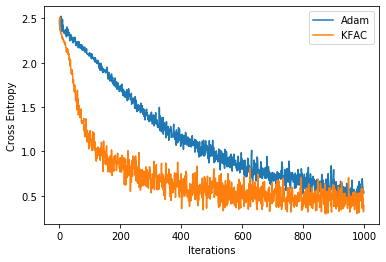

In [48]:
import matplotlib.pyplot as plt
plt.plot(np.arange(len(adam_losses)), adam_losses)
plt.plot(np.arange(len(kfac_losses)), kfac_losses)
plt.legend(['Adam', 'KFAC'])
plt.xlabel('Iterations')
plt.ylabel('Cross Entropy')
plt.savefig('filename.png', dpi=300)
plt.show()